# Circular diagrams and the rewrite rules

The computing core: `CircularGraph` (nodes with an OPEN arm count — merging
collapses whole clusters into one node), decorated diagrams with polynomial
region labels, and the rule driver `reduce_to_circular_leave` that reduces a
double leaf to a sum of irreducible circular leaves. This is the machinery a
future paper about the rules will describe; the rule registry `CIRCULAR_RULES`
in the source is always the authoritative rule list.

In [1]:
using DiagrammaticHecke
debug_circular(true)   # arm, region and leaf numbers in every picture

true

## 1. From WordGraph to CircularGraph

`circular(g)` converts; `circular_morphism(m)` keeps the boundary marker (only
a MORPHISM carries cuts, hence the mark and the region distances).

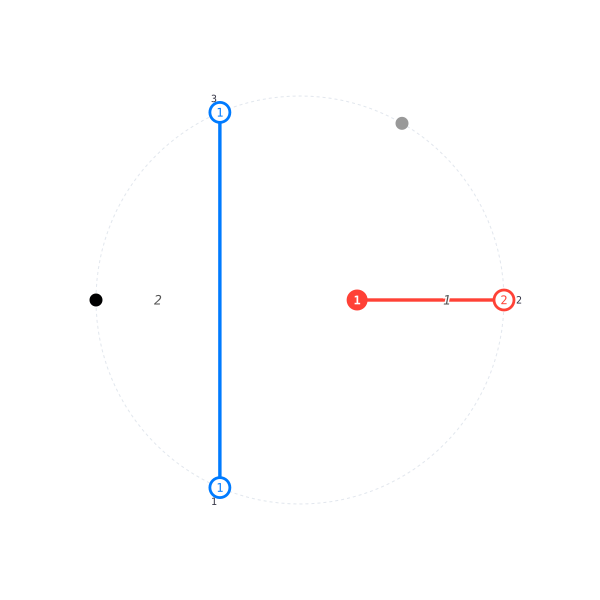

arm_count(fm.graph.nodes[1]) = 1
circular_degree(fm.graph) = 1


In [2]:
m = light_leaf([1,2,1], [1,0,1])
fm = circular_morphism(m)
display(fm)
@show arm_count(fm.graph.nodes[1]) circular_degree(fm.graph);

## 2. Structural reduction: `reduce_circular`

`CIRCULAR_RULES` is the registry of weight-decreasing structural rules
(C1–C20: dot/trivalent absorption, merges, the two-colour braid rules, the
big-node family). `reduce_circular` applies them to a normal form; the
termination measure is `circular_weight`.

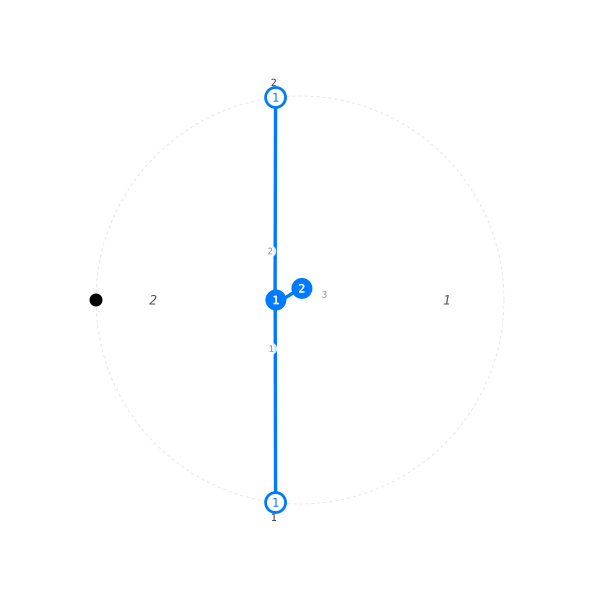

history = [:merge]
Coefficient 

1   degree 0
   Labels: 

—   outer: 1   nodes: Tuple{Symbol, Vector{Int64}}[]


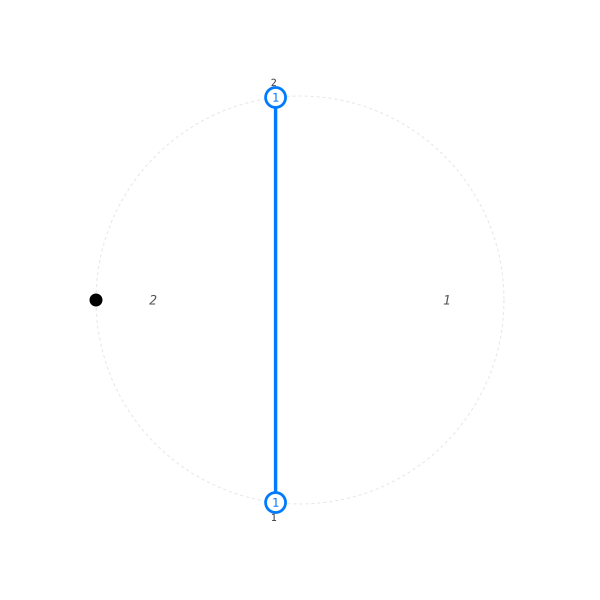

In [3]:
g = circular(unit_graph())
display(g)
combo, history = reduce_circular(g)   # normal form as a sum + fired rule names
@show history
show_combo(combo)

## 3. Decorated diagrams and D4

A `CircularDecorated` carries one polynomial label per region. The D4 rule
("dot + connection") turns a dot next to a matching node into a two-term sum
with `±α/2` labels; scalars may only be pulled out of the region at marker
distance 0. `show_combo` draws every term of a sum — never print a sum as a
bare term count.

Coefficient 

1   degree 1
   Labels: —   outer: 1   nodes: [(:mono, 

[2])]


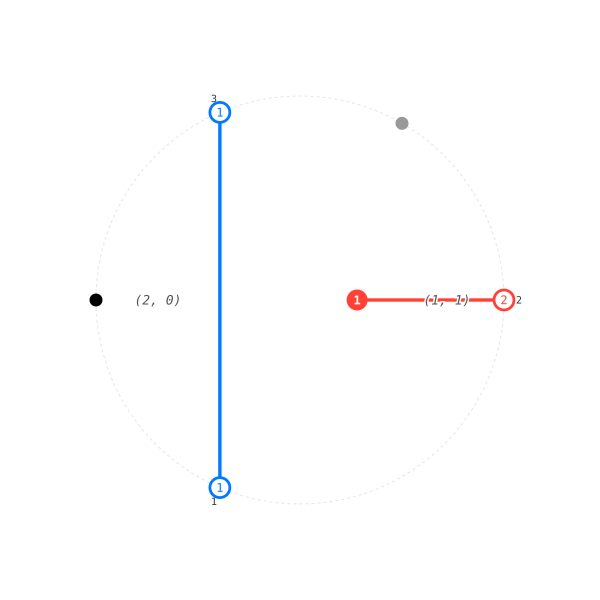

In [4]:
fdm = CircularDecoratedMorphism(fm, fill(one(SoergelPoly), region_count(fm.graph)))
combo = reduce_to_circular_leave(fdm)
show_combo(combo; m = fm)

## 4. The degree invariant

On every term of the reduction, `degree(DL) == degree(label) +
circular_degree(leaf)`. Together with the pairing table this gives the graded
test that the circular leaves form a basis (`test1_graded`).

In [5]:
x = [1,2,1]
dls = double_leaves(x, x)
combos = [reduce_to_circular_leave(CircularDecoratedMorphism(circular_morphism(d.morphism),
              fill(one(SoergelPoly), region_count(circular_morphism(d.morphism).graph))))
          for d in dls]
degs = circular_leaf_degrees(combos)
r = test1_graded(x, x, [d.degree for d in dls], degs.degrees)
@show r.consistent
[(row.degree, row.n_dl, row.pairing) for row in r.rows]   # 0:2 2:5 4:4 6:1

r.consistent = true


4-element Vector{Tuple{Int64, Int64, Int64}}:
 (0, 2, 2)
 (2, 5, 5)
 (4, 4, 4)
 (6, 1, 1)

## 5. Step-by-step pictures

`circular_trace` / `show_circular_step_row` render a reduction as an image
equation `D → c₁·D₁ + c₂·D₂ + …` — the format the paper figures will use.

Step 1: :circular_rules 2 nodes → 0 nodes
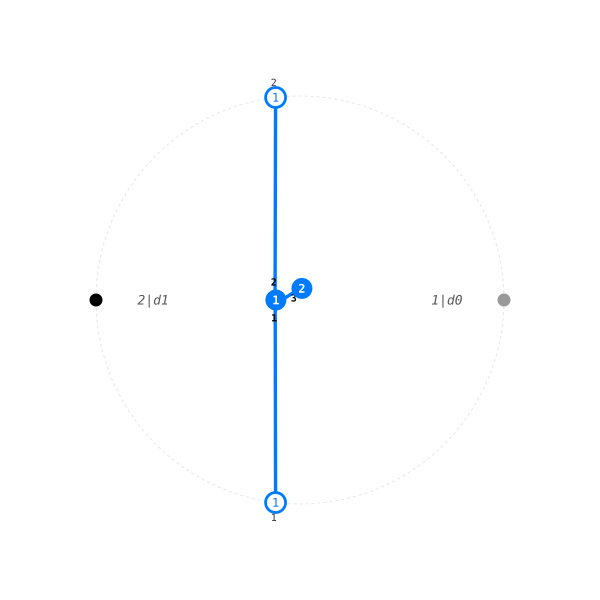
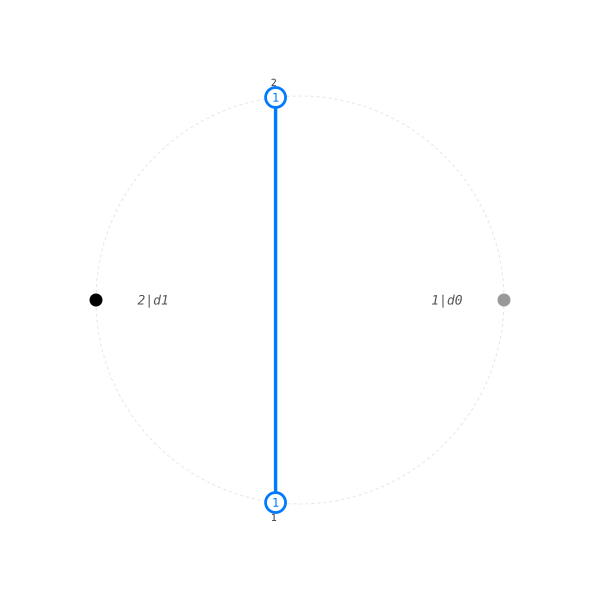

FIXED POINT after 1 steps:  1 terms, node counts [0]


Step sequence: [:circular_rules]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(11, 0 nodes, 1 edges))

In [6]:
m0 = circular_morphism(morphism_graph(unit_graph(), 0, 0))
circular_trace(circular(unit_graph()), m0)   # draws every step D → c₁·D₁ + …

## 6. Saving and loading

The circular side has the same formats with one line swapped: `.fwg` for a
`CircularGraph`, `.fwgm` for a `CircularMorphismGraph`. Only the node line
differs from `.wg`, because a `CircularNode` carries an arbitrary arm vector
where a `Node` carries colours and `m`.

In [7]:
print(circulargraph_to_string(fm.graph))
g2 = circulargraph_from_string(circulargraph_to_string(fm.graph))
@show circular_canonical_key(g2) == circular_canonical_key(fm.graph);

#fwg 1
word 112
# nodes
n mono 2
# edges
e 2 L2 n1.1
e 1 L1 L3


circular_canonical_key(g2) == circular_canonical_key(fm.graph) = true


A decorated diagram needs its labels too. `.cd` wraps an `.fwg` body in a
label header, with every polynomial written through `soergelpoly_to_string`, so
the file stays readable.

In [8]:
fd   = circular_decorated(fm.graph, [alpha(1), alpha(2), one(SoergelPoly)][1:region_count(fm.graph)])
path = joinpath(mktempdir(), "leaf.cd")
save_circulardecorated(path, fd)
println(read(path, String))
fd2 = load_circulardecorated(path)
@show fd2.region_labels == fd.region_labels fd2.outer_label == fd.outer_label;

#fd 1
labels 1,0,0:1/1 | 0,1,0:1/1
outer 1
#fwg 1
word 112
# nodes
n mono 2
# edges
e 2 L2 n1.1
e 1 L1 L3


fd2.region_labels == fd.region_labels = true
fd2.outer_label == fd.outer_label = true


## 7. Debug and display switches

Every notebook here opens with `debug_circular(true)`. That is one of several
switches, and they fall into three groups.

**What a picture shows.**

| switch | effect |
|---|---|
| `debug_circular(true)` | arm numbers, node numbers and region numbers in every circular picture. Without it one cannot say which region a rule refers to. |
| `debug_labels(true)` | writes the pair `(label, distance)` into each cell instead of just the polynomial. |
| `show_circular_step(fd, m)` | the picture WITH the boundary marking, plus `number|distance,label` per region and the wiring below it. A bare `CircularGraph` has no cuts, so `display(g)` draws the canonical mark only. |
| `notebook_display_sink!()` | only needed outside a notebook: registers a display that accepts `image/svg+xml`, so `julia script.jl` can run notebook-style code. |

Two traps that belong to the first row: draw the DECORATED object, not the bare
graph (`display(fd)` writes the region polynomials, `display(fd.graph)` does
not), and never `display(fm.graph)` on a morphism — that loses the real marking.

**How loud the machinery is.**

| switch | effect |
|---|---|
| `CIRCULAR_WARN_NOT_NORMAL[]` | default `true`: printing a term reports dots whose distance word can still be braided home, i.e. "this is not a normal form". Set to `false` when it floods the output. |
| `dl_warnings!(false)` | silences the basis warnings of `dl`/`circular_dl` — for callers that report the finding themselves (notebooks 08 and 10 do). |
| `CIRCULAR_EXPLOSION_ENABLED[]` | default `true`: remembers the deepest diagram of a reduction so it can be written to disk after a blow-up. `false` for a timing run. |

**Which rules run.** These change results, not output: `CIRCULAR_ZAMO_ENABLED`,
`CIRCULAR_DOT_FUSION_ENABLED`, `CIRCULAR_REX_FUSION_ENABLED`,
`CIRCULAR_DOT_SLIDE_ENABLED` and `CIRCULAR_DOT_POLICY`. PLAN.md says what
each default means; a `false` default marks a rule whose place is not
settled, not one that is wrong.

**Checking a diagram.** `check_wiring(g)` returns the violations,
`show_wiring_check(g)` prints them with the Euler number, and `euler(g) == 2` is
the planarity test. Every fixture in the test suite is checked this way.

In [9]:
@show debug_circular() debug_labels()
@show CIRCULAR_WARN_NOT_NORMAL[] CIRCULAR_EXPLOSION_ENABLED[]
@show CIRCULAR_ZAMO_ENABLED[] CIRCULAR_DOT_FUSION_ENABLED[] CIRCULAR_REX_FUSION_ENABLED[]
@show CIRCULAR_DOT_SLIDE_ENABLED[] CIRCULAR_DOT_POLICY[]
show_wiring_check(circular(unit_graph()))

debug_circular() = true
debug_labels() = false
CIRCULAR_WARN_NOT_NORMAL[] = true
CIRCULAR_EXPLOSION_ENABLED[] = true
CIRCULAR_ZAMO_ENABLED[] = true
CIRCULAR_DOT_FUSION_ENABLED[] = true
CIRCULAR_REX_FUSION_ENABLED[] = true
CIRCULAR_DOT_SLIDE_ENABLED[] = false
CIRCULAR_DOT_POLICY[] = true


check_wiring: no violations  (V−E+F = 2)


**One diagram, one option at a time.** `debug_circular(true)` turns on three
overlays at once. `display_circular_tutte` takes them separately, so below is one
small double leaf — 4 nodes, 5 regions, 8 boundary leaves — drawn once per
option. Compare each picture with the bare one.

length(dbg.graph.nodes) = 4
region_count(dbg.graph) = 5
length(letters(dbg.graph.word)) = 8
bare — no overlay at all


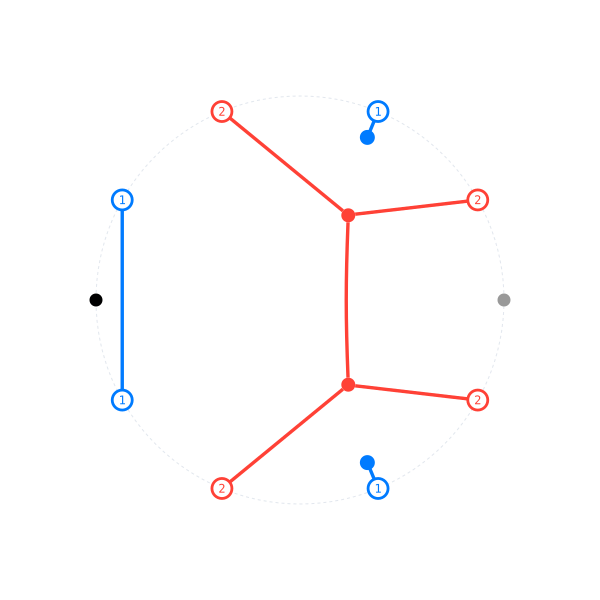

In [10]:
dbg = circular_morphism(double_leaves([1,2,1,2], [1,2,1,2])[36].morphism)
@show length(dbg.graph.nodes) region_count(dbg.graph) length(letters(dbg.graph.word))
off = (; slot_numbers = false, cell_numbers = false, leaf_numbers = false)
println("bare — no overlay at all")
display_circular_tutte(dbg; off...)

`leaf_numbers` writes the index `k` of `Leaf(k)` just outside the dashed
boundary circle, so one can see which boundary letter an arm runs to without
reading the edge list.

leaf_numbers = true


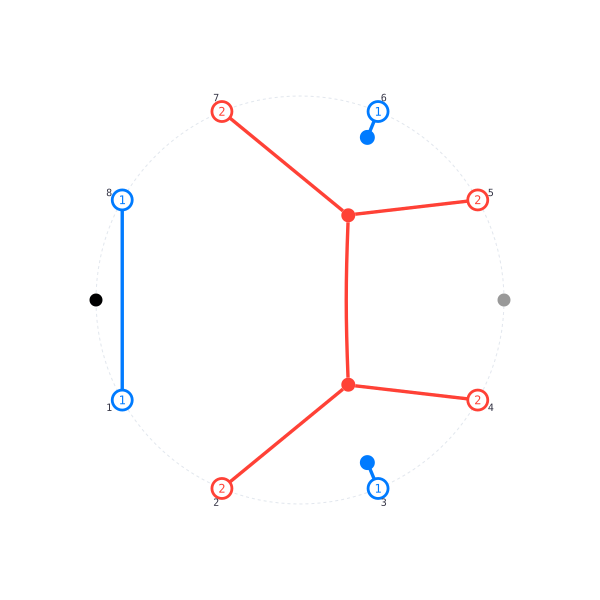

In [11]:
println("leaf_numbers = true")
display_circular_tutte(dbg; off..., leaf_numbers = true)

`slot_numbers` numbers the node arms (and the nodes themselves). This is what
one needs to read a `NodePort(node, slot)` off the picture.

slot_numbers = true


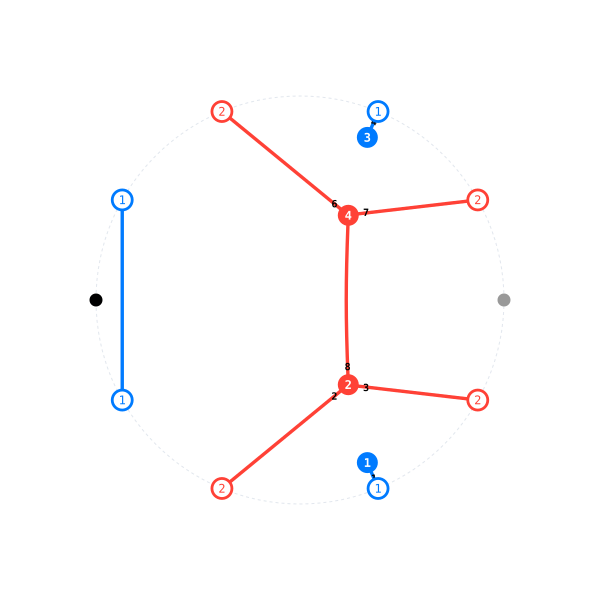

In [12]:
println("slot_numbers = true")
display_circular_tutte(dbg; off..., slot_numbers = true)

`cell_numbers` writes the REGION number into each region — the index into a
label vector such as `fill(one(SoergelPoly), region_count(g))`.

cell_numbers = true   (cell_labels = :numbers, the default)


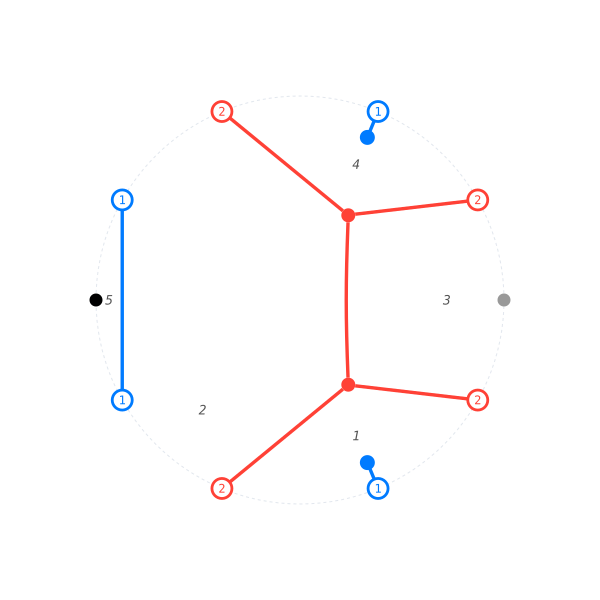

In [13]:
println("cell_numbers = true   (cell_labels = :numbers, the default)")
display_circular_tutte(dbg; off..., cell_numbers = true)

`cell_labels` changes WHAT is written there, once `cell_numbers = true`.
`:distances` gives the BFS distance to the black marking, `:words` the region
word (`ε` at the mark), `:words_num` both, `:none` nothing. Distances and words
need the marking, so draw the MORPHISM, not `m.graph`.

distances: [2, 1, 2, 2, 0]


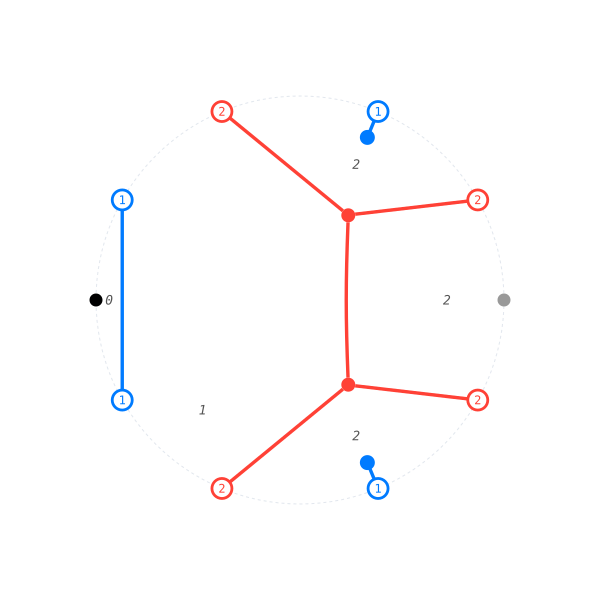

In [14]:
println("distances: ", circular_region_distances(dbg))
display_circular_tutte(dbg; off..., cell_numbers = true, cell_labels = :distances)

region words: 

Union{Nothing, Vector{Int64}}[[1, 2], [1], [1, 2], [1, 2], Int64[]]


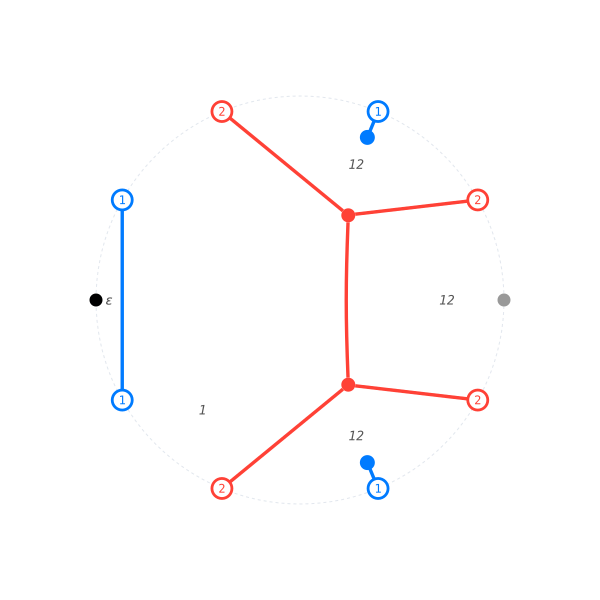

In [15]:
println("region words: ", circular_region_tree_words(dbg))
display_circular_tutte(dbg; off..., cell_numbers = true, cell_labels = :words)

`region_tree` overlays the dual graph: one arrow per tree edge from the marked
region outwards, labelled with the colour crossed there. Reading the arrows from
the mark to a region spells out that region's word. It is not a
`display_circular_tutte` keyword — go through `circular_tutte_svg`.

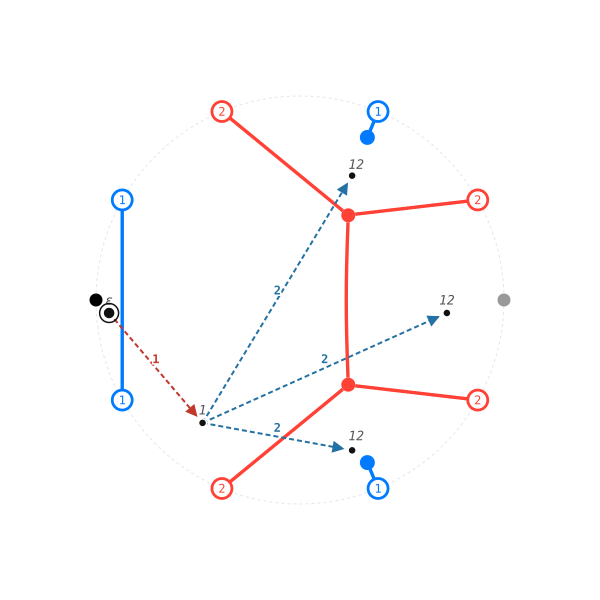

In [16]:
display("image/svg+xml",
        circular_tutte_svg(dbg; slot_numbers = false, leaf_numbers = false,
                           cell_numbers = true, cell_labels = :words, region_tree = true))

`debug_circular(true)` is `slot_numbers`, `cell_numbers` and `leaf_numbers`
together — the default every notebook here opens with.

all three at once


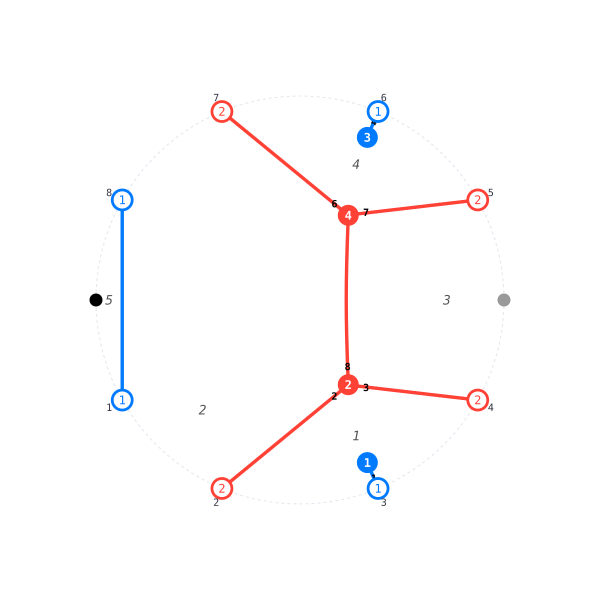

In [17]:
println("all three at once")
display_circular_tutte(dbg; slot_numbers = true, cell_numbers = true, leaf_numbers = true)

Two more that draw rather than switch: `show_wiring_check` prints the
violations with the Euler number, and `display_cell_distance` is the
`WordGraph` counterpart of `:distances`.

In [18]:
show_wiring_check(dbg.graph)

check_wiring: no violations  (V−E+F = 2)
